## Zero-Shot Cross-Condition Transfer Experiment

For each of six transfer directions (PD→HD, HD→PD, PD→ALS, ALS→PD, HD→ALS, ALS→HD), a source model is trained once on the full source pool (source condition strides + Control Group A) using the modal hyperparameters identified during within-condition LOSO-CV.
The fitted model is then evaluated on the target pool (target condition + Control Group B) without any retraining or hyperparameter tuning on target data — this is a genuinely zero-shot evaluation for both classes, since neither the target pathological subjects nor the Control B subjects were seen during training.
All six transfer directions are bidirectional and asymmetric: PD→HD and HD→PD use different source models, different training pools, and evaluate on different target sets.
All 42 permutation p-values equal 0.0000, confirming that every classifier in every direction performs significantly above chance.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.dpi':       150,
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
})

RESULTS_DIR = Path('../experiments/results')
FIGURES_DIR = Path('../report/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load Step 3 results ───────────────────────────────────────────────────────
with open(RESULTS_DIR / 'cross_condition_results.json') as f:
    cc = json.load(f)

# ── Load Step 2 within-condition results ──────────────────────────────────────
with open(RESULTS_DIR / 'pd_results.json') as f:
    pd_res = json.load(f)
with open(RESULTS_DIR / 'hd_results.json') as f:
    hd_res = json.load(f)
with open(RESULTS_DIR / 'als_results.json') as f:
    als_res = json.load(f)

DIRECTIONS = ['pd_to_hd', 'hd_to_pd', 'pd_to_als', 'als_to_pd', 'hd_to_als', 'als_to_hd']
DIR_LABELS = ['PD→HD', 'HD→PD', 'PD→ALS', 'ALS→PD', 'HD→ALS', 'ALS→HD']
CLF_NAMES  = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABELS = ['RF', 'KNN', 'SVM', 'DT', 'QDA', 'XGBoost', 'LightGBM']

# Best classifier per source condition (used for confusion matrices and per-subject analysis)
BEST_CLF = {'pd': 'rf', 'hd': 'rf', 'als': 'knn'}

# Per-classifier within-condition F1 (each classifier's own baseline, not just the best)
WITHIN_F1_PER_CLF = {
    'pd':  {clf: pd_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
    'hd':  {clf: hd_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
    'als': {clf: als_res['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES},
}

# Best-classifier within-condition F1 per source condition (for heatmap title reference)
WITHIN_F1 = {
    'pd':  pd_res['classifiers'][BEST_CLF['pd']]['f1_macro'],
    'hd':  hd_res['classifiers'][BEST_CLF['hd']]['f1_macro'],
    'als': als_res['classifiers'][BEST_CLF['als']]['f1_macro'],
}

print(f"Loaded {len(cc)} transfer directions.")
print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")
print()
print("Per-classifier within-condition F1:")
for cond in ('pd', 'hd', 'als'):
    vals = ', '.join(f"{clf.upper()}={v:.4f}" for clf, v in WITHIN_F1_PER_CLF[cond].items())
    print(f"  {cond.upper()}: {vals}")


Loaded 6 transfer directions.
Figures will be saved to: /Users/Ali/Projects/Heyteam/Gait Classification/gait-transfer-ndd/report/figures

Per-classifier within-condition F1:
  PD: RF=0.7777, KNN=0.7110, SVM=0.7194, DT=0.7434, QDA=0.6406, XGB=0.7727, LGBM=0.7251
  HD: RF=0.8995, KNN=0.8669, SVM=0.8524, DT=0.8980, QDA=0.5799, XGB=0.8937, LGBM=0.8703
  ALS: RF=0.7737, KNN=0.8758, SVM=0.8221, DT=0.7329, QDA=0.6905, XGB=0.7854, LGBM=0.7329


,direction,clf,cross_f1,within_f1,delta_f1,stride_ci_lower,stride_ci_upper,subj_ci_lower,subj_ci_upper,p_value
0,pd_to_hd,rf,0.8208,0.7777,-0.0431,0.8108,0.8309,0.6676,0.9141,0.0000
1,pd_to_hd,knn,0.7260,0.7110,-0.0149,0.7135,0.7384,0.5777,0.8310,0.0000
2,pd_to_hd,svm,0.7829,0.7194,-0.0636,0.7715,0.7948,0.6161,0.8993,0.0000
3,pd_to_hd,dt,0.7609,0.7434,-0.0174,0.7496,0.7721,0.5733,0.8851,0.0000
4,pd_to_hd,qda,0.6414,0.6406,-0.0008,0.6296,0.6522,0.4923,0.7650,0.0000
5,pd_to_hd,xgb,0.8773,0.7727,-0.1046,0.8689,0.8858,0.7450,0.9600,0.0000
6,pd_to_hd,lgbm,0.8011,0.7251,-0.0760,0.7893,0.8122,0.6195,0.9185,0.0000
7,hd_to_pd,rf,0.6707,0.8995,+0.2288,0.6582,0.6831,0.4662,0.8451,0.0000
8,hd_to_pd,knn,0.6775,0.8669,+0.1895,0.6656,0.6899,0.4828,0.8270,0.0000
9,hd_to_pd,svm,0.6825,0.8524,+0.1699,0.6696,0.6950,0.4895,0.8436,0.0000


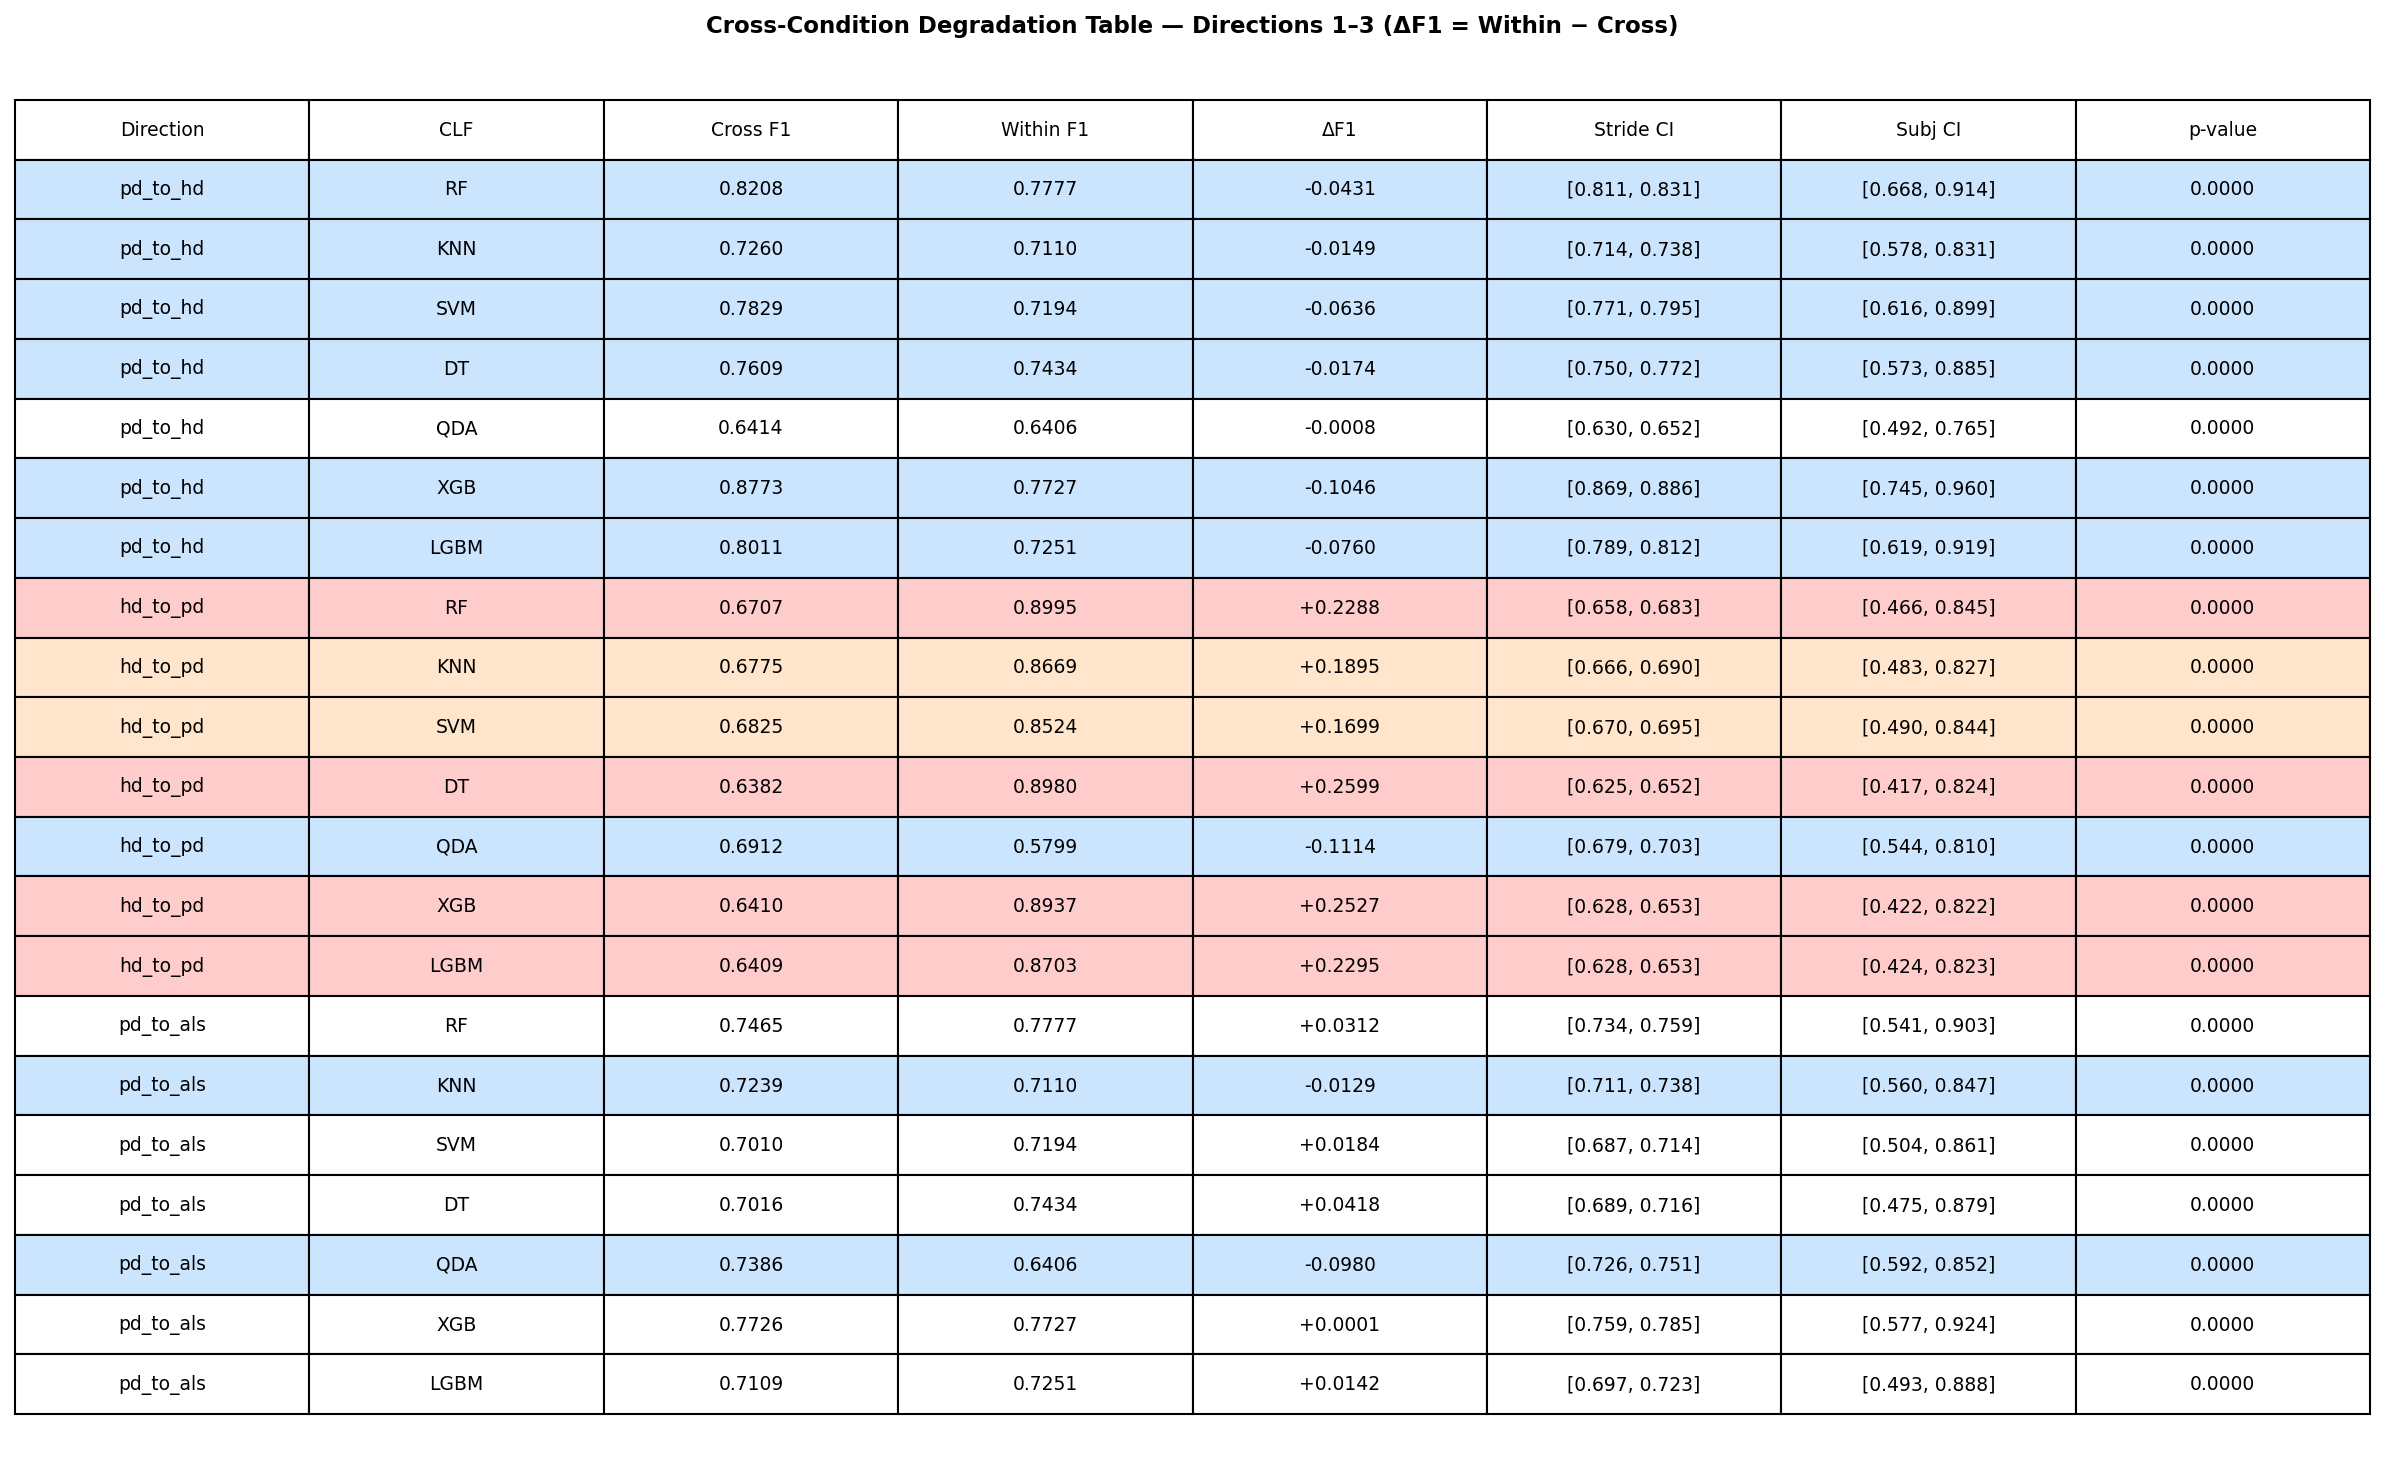

Saved: degradation_table_part1.pdf / .png


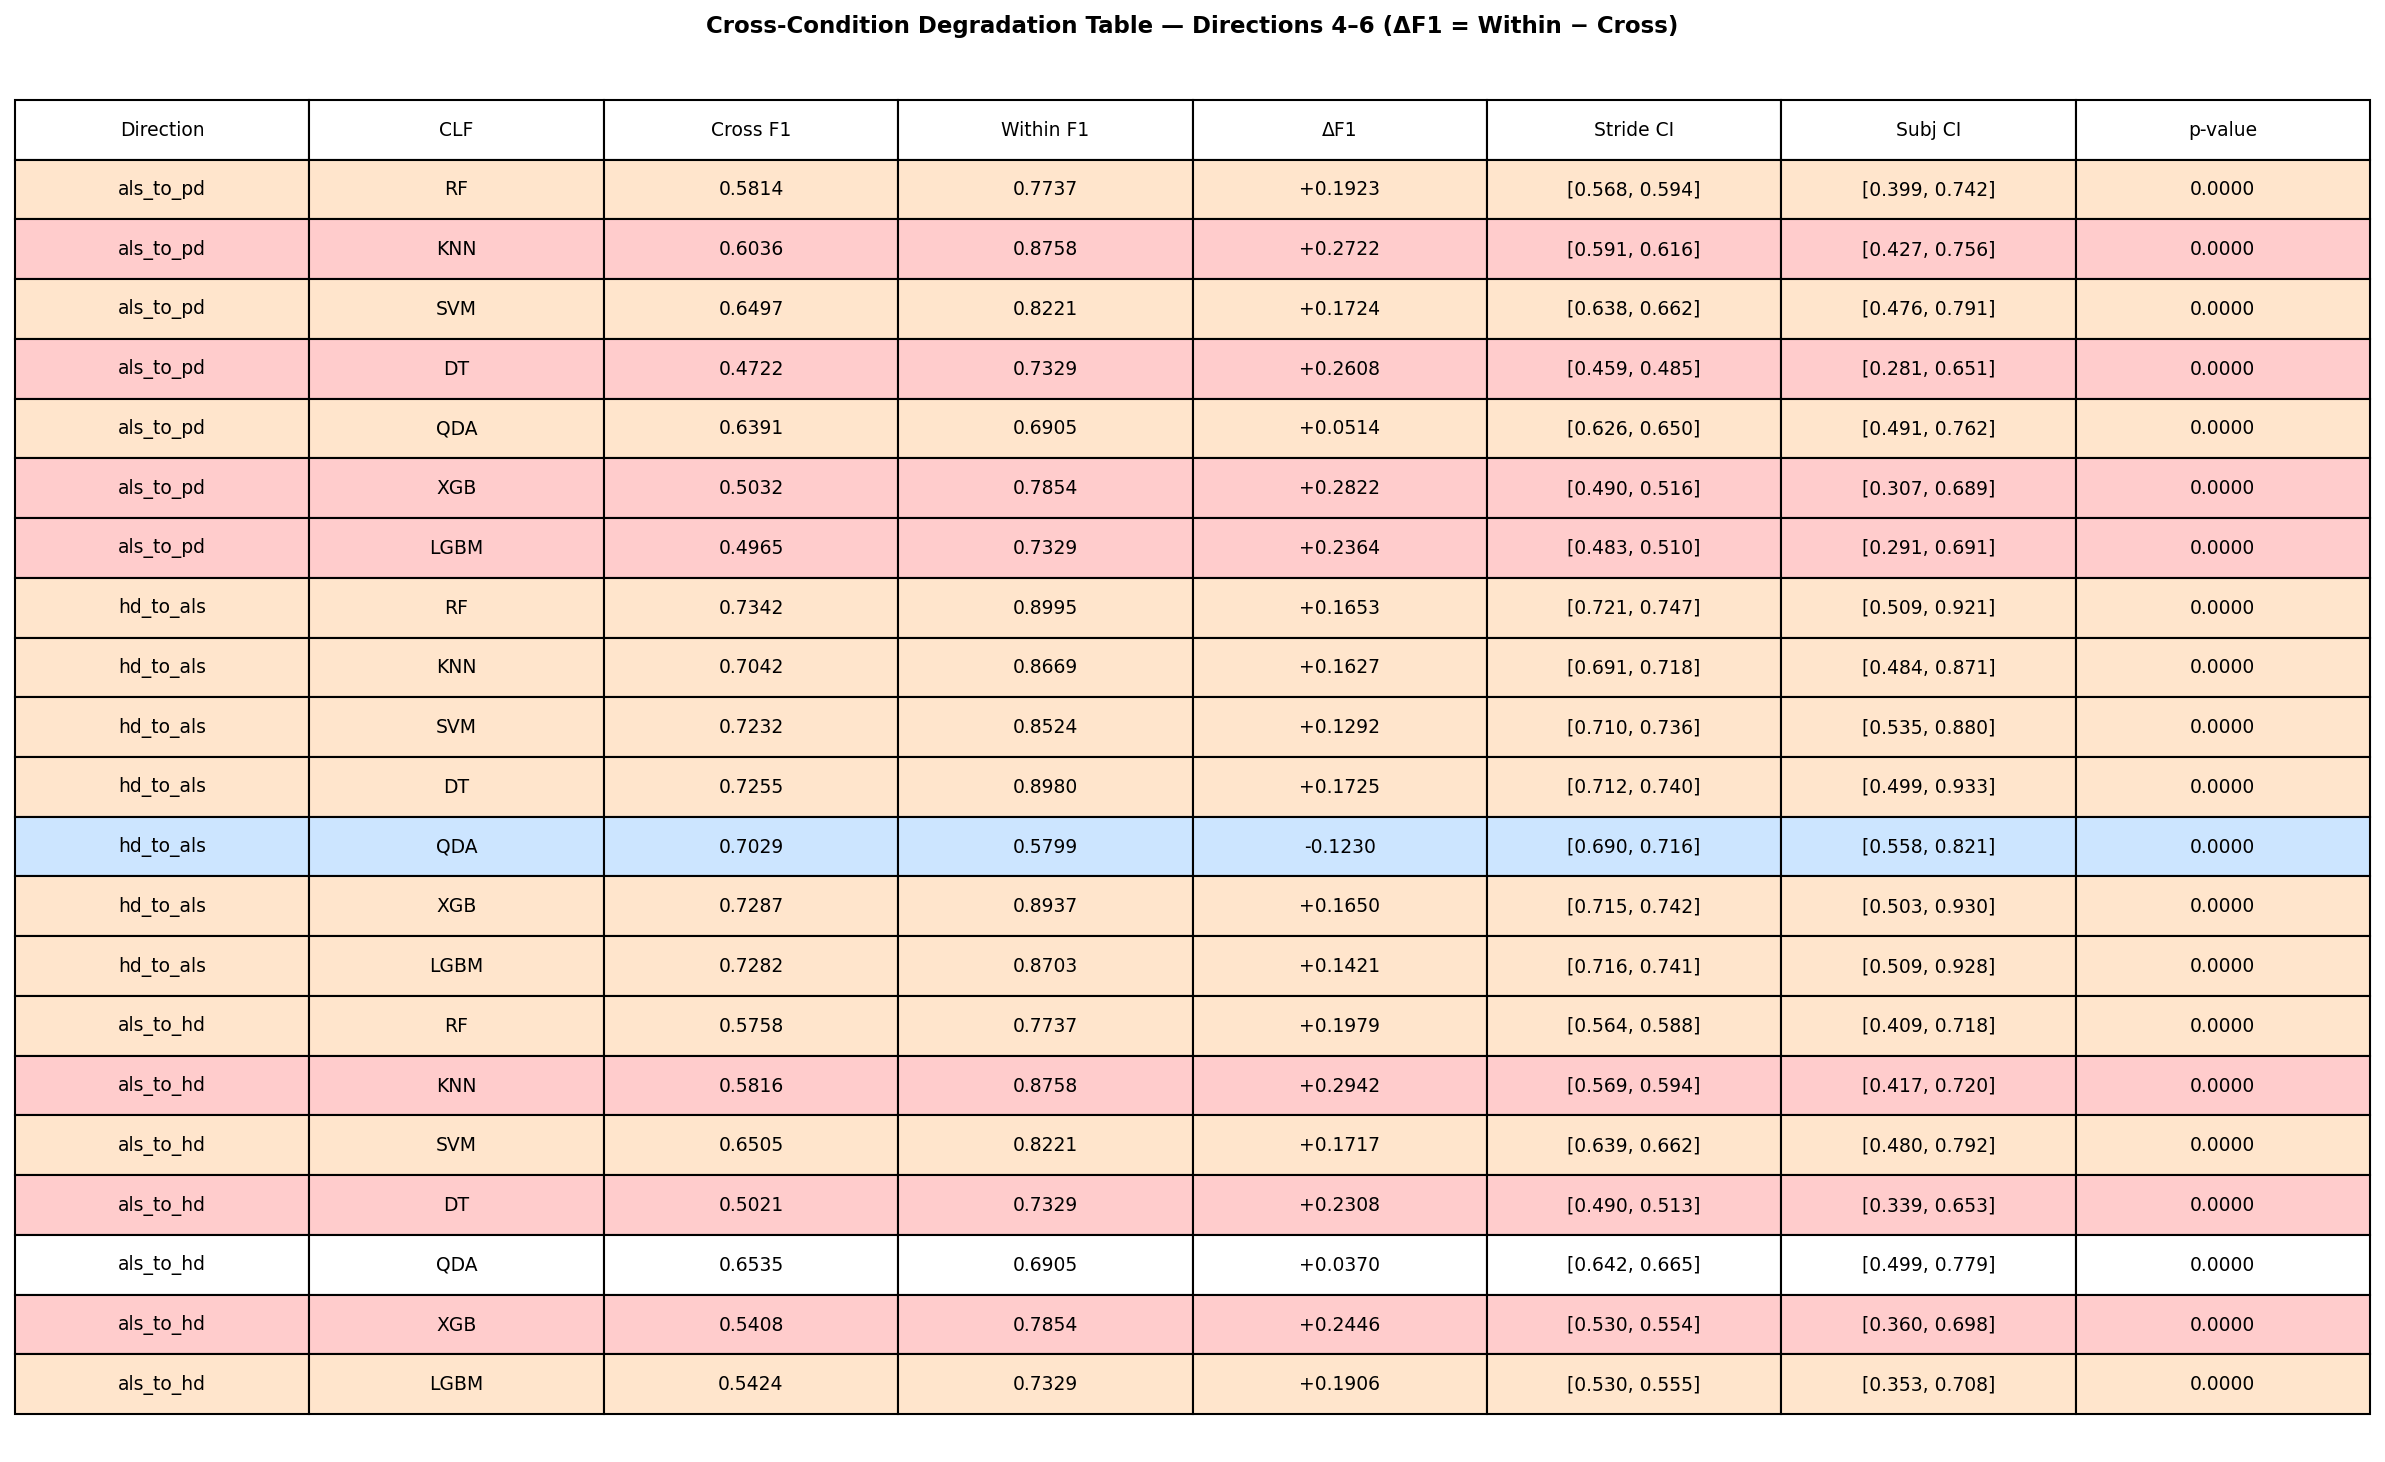

Saved: degradation_table_part2.pdf / .png


In [2]:
rows = []
for direction in DIRECTIONS:
    src = direction.split('_to_')[0]
    d = cc[direction]
    for clf in CLF_NAMES:
        v = d['classifiers'][clf]
        within_f1 = WITHIN_F1_PER_CLF[src][clf]
        rows.append({
            'direction':       direction,
            'clf':             clf,
            'cross_f1':        v['f1_macro'],
            'within_f1':       within_f1,
            'delta_f1':        round(within_f1 - v['f1_macro'], 6),
            'stride_ci_lower': v['f1_macro_ci_lower'],
            'stride_ci_upper': v['f1_macro_ci_upper'],
            'subj_ci_lower':   v['f1_macro_subj_ci_lower'],
            'subj_ci_upper':   v['f1_macro_subj_ci_upper'],
            'p_value':         v['permutation_p_value'],
        })

df_deg = pd.DataFrame(rows)

styled = (
    df_deg.style
    .background_gradient(subset=['delta_f1'], cmap='RdBu_r', vmin=-0.45, vmax=0.45)
    .format({
        'cross_f1':        '{:.4f}',
        'within_f1':       '{:.4f}',
        'delta_f1':        '{:+.4f}',
        'stride_ci_lower': '{:.4f}',
        'stride_ci_upper': '{:.4f}',
        'subj_ci_lower':   '{:.4f}',
        'subj_ci_upper':   '{:.4f}',
        'p_value':         '{:.4f}',
    })
    .set_caption('Cross-Condition Degradation Table (\u0394F1 = Within \u2212 Cross, per classifier)')
)
display(styled)

# Matplotlib table for PDF rendering \u2014 split into two halves for readability
for half_idx, (half_label, half_df) in enumerate(
    [('Directions 1\u20133', df_deg.iloc[:21]), ('Directions 4\u20136', df_deg.iloc[21:])],
    start=1
):
    fig_t, ax_t = plt.subplots(figsize=(16, 10))
    ax_t.axis('off')

    col_labels = ['Direction', 'CLF', 'Cross F1', 'Within F1', '\u0394F1',
                  'Stride CI', 'Subj CI', 'p-value']
    table_data = []
    row_colors = []
    for _, row in half_df.iterrows():
        table_data.append([
            row['direction'], row['clf'].upper(),
            f"{row['cross_f1']:.4f}",
            f"{row['within_f1']:.4f}",
            f"{row['delta_f1']:+.4f}",
            f"[{row['stride_ci_lower']:.3f}, {row['stride_ci_upper']:.3f}]",
            f"[{row['subj_ci_lower']:.3f}, {row['subj_ci_upper']:.3f}]",
            f"{row['p_value']:.4f}",
        ])
        delta = row['delta_f1']
        if delta > 0.20:
            row_colors.append(['#ffcccc'] * 8)
        elif delta > 0.05:
            row_colors.append(['#ffe5cc'] * 8)
        elif delta < -0.01:
            row_colors.append(['#cce5ff'] * 8)
        else:
            row_colors.append(['#ffffff'] * 8)

    tbl = ax_t.table(
        cellText=table_data,
        colLabels=col_labels,
        cellColours=row_colors,
        loc='center',
        cellLoc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 2.0)

    # Title placed well above the table using figure text, not ax title
    fig_t.text(0.5, 0.97,
               f'Cross-Condition Degradation Table \u2014 {half_label} (\u0394F1 = Within \u2212 Cross)',
               ha='center', va='top', fontsize=11, fontweight='bold')

    fig_t.tight_layout(rect=[0, 0, 1, 0.95])
    for ext in ('pdf', 'png'):
        fig_t.savefig(FIGURES_DIR / f'degradation_table_part{half_idx}.{ext}')
    plt.show()
    plt.close(fig_t)
    print(f"Saved: degradation_table_part{half_idx}.pdf / .png")


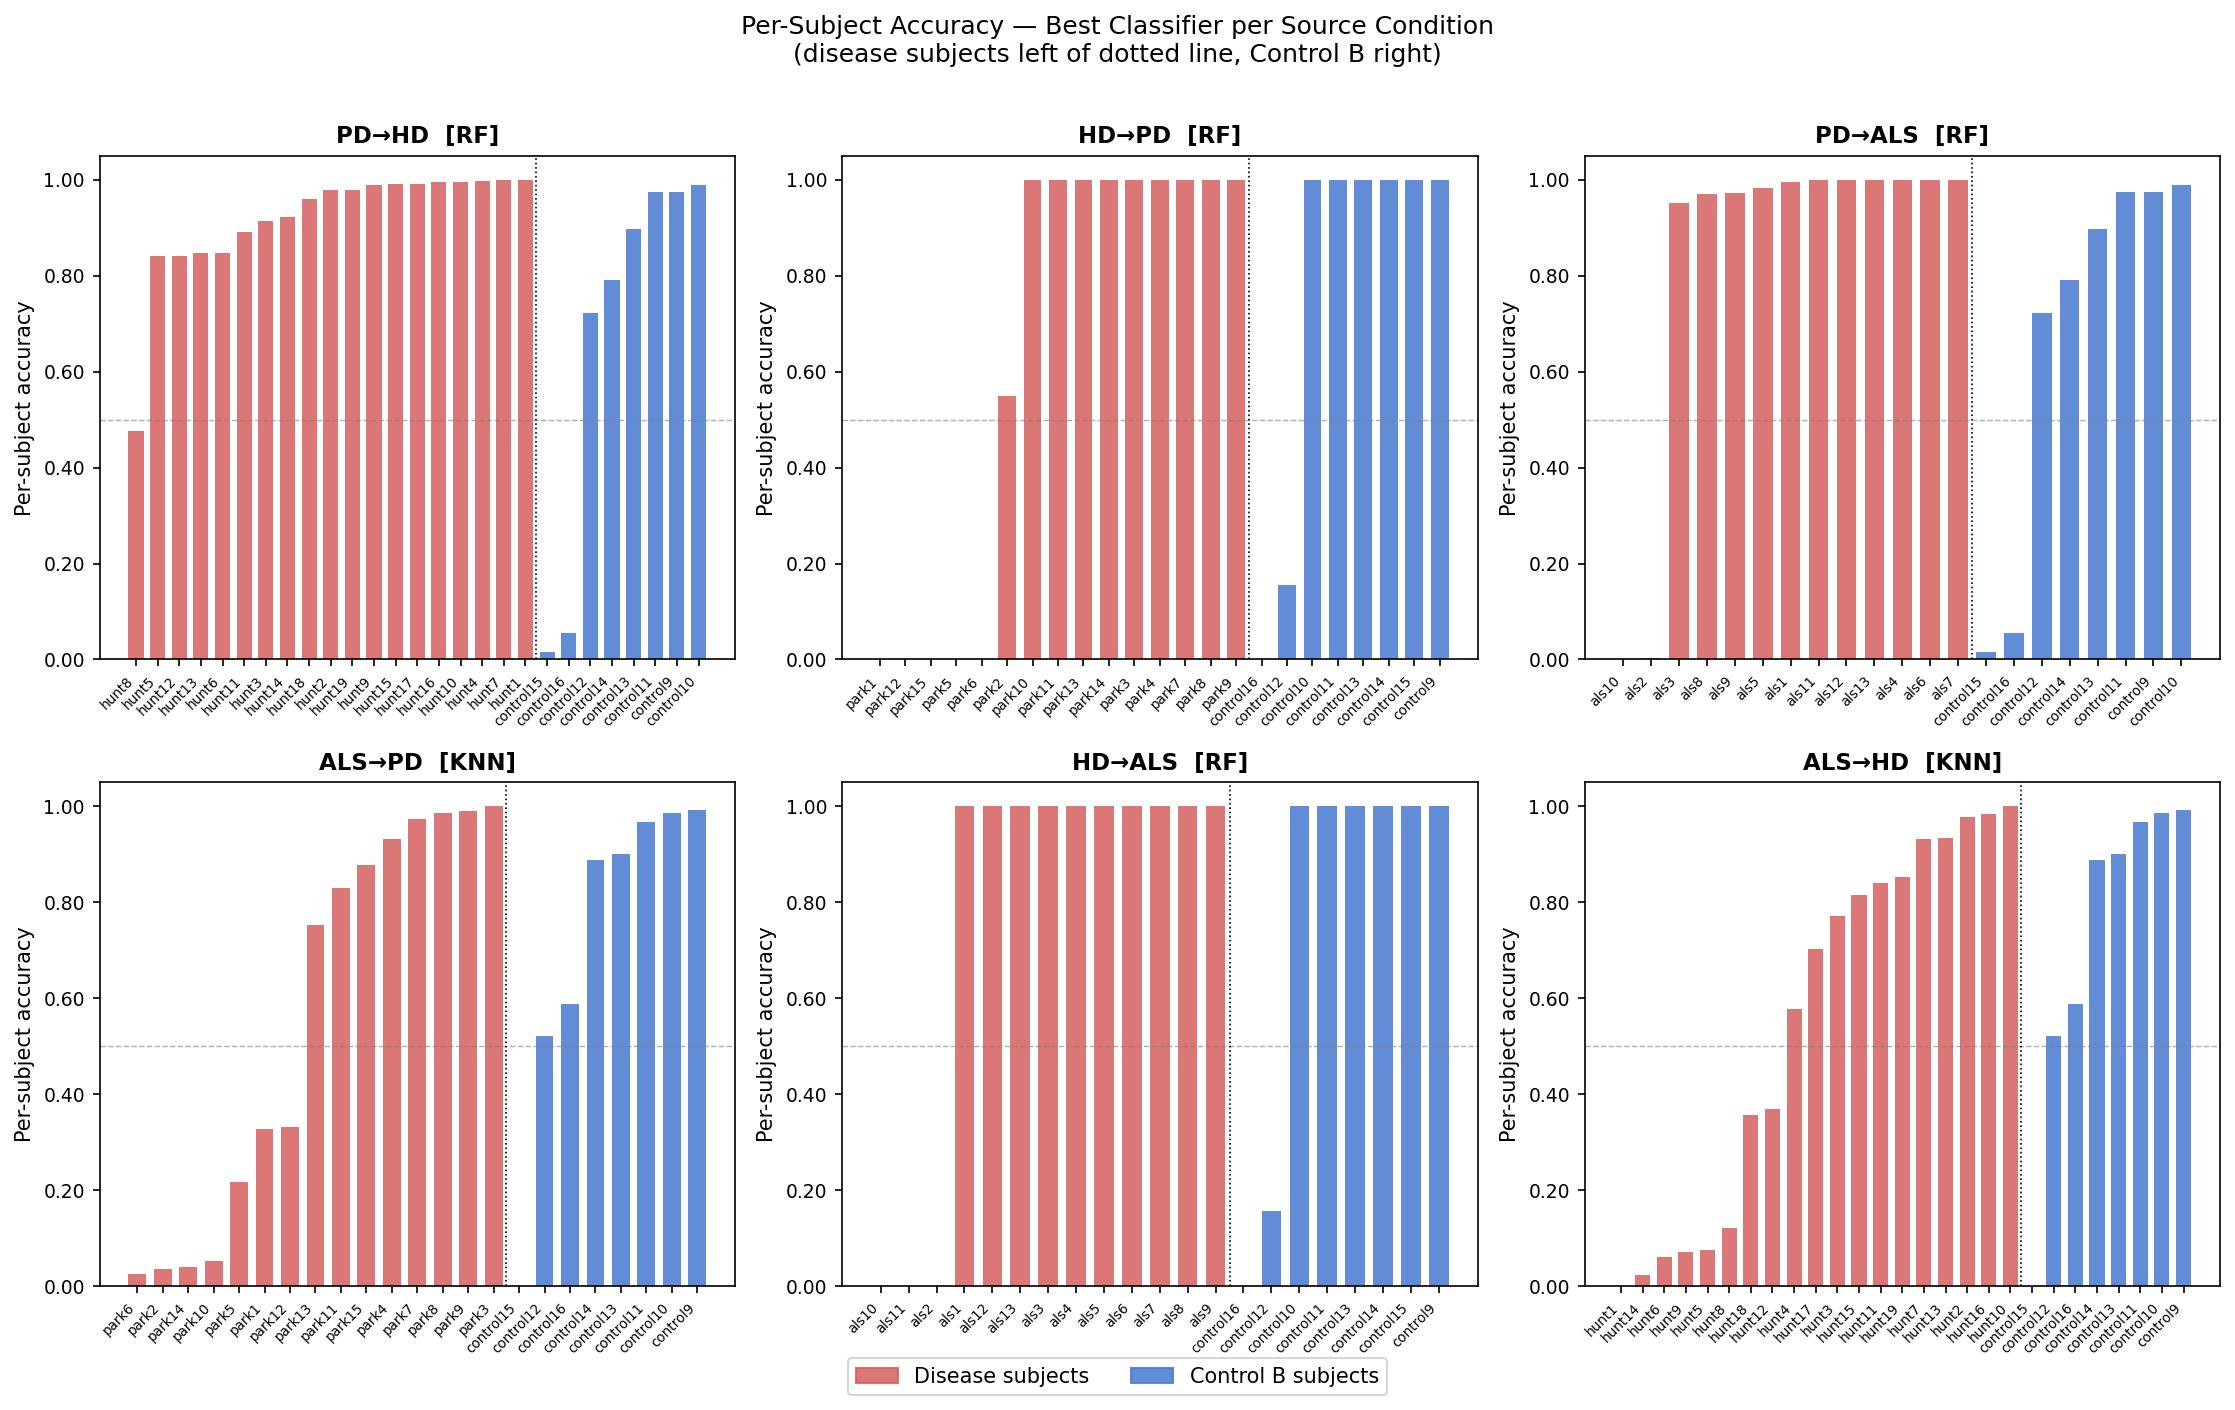

Saved: per_subject_accuracy.pdf / .png

Per-subject accuracy summary (all directions, best clf per source):
                     count   mean    min    max
dir_label condition                            
ALS→HD    control        8  0.730  0.000  0.993
          disease       19  0.551  0.000  1.000
ALS→PD    control        8  0.730  0.000  0.993
          disease       15  0.558  0.026  1.000
HD→ALS    control        8  0.769  0.000  1.000
          disease       13  0.769  0.000  1.000
HD→PD     control        8  0.769  0.000  1.000
          disease       15  0.637  0.000  1.000
PD→ALS    control        8  0.677  0.015  0.989
          disease       13  0.837  0.000  1.000
PD→HD     control        8  0.677  0.015  0.989
          disease       19  0.919  0.477  1.000

Subjects with accuracy < 0.5 (transfer failure):
dir_label subject_id condition  n_strides  accuracy
    PD→HD  control15   control        198  0.015152
    PD→HD  control16   control        250  0.056000
    PD→HD     

In [3]:
# ── Per-subject accuracy analysis ────────────────────────────────────────────
# Uses the best classifier per source condition (RF for PD/HD-source, KNN for ALS-source).
# Accuracy is used instead of F1 because each subject belongs to a single class,
# making F1 macro undefined for single-class test sets.
# target_subject_ids is stored at direction level (parallel to y_true / y_pred).

subj_rows = []
for direction in DIRECTIONS:
    src = direction.split('_to_')[0]
    tgt = direction.split('_to_')[1]
    clf_name = BEST_CLF[src]
    d = cc[direction]

    y_true = np.array(d['classifiers'][clf_name]['y_true'])
    y_pred = np.array(d['classifiers'][clf_name]['y_pred'])
    subj_ids = np.array(d['target_subject_ids'])

    for sid in np.unique(subj_ids):
        mask = subj_ids == sid
        yt = y_true[mask]
        yp = y_pred[mask]
        acc = np.mean(yt == yp)
        label = int(yt[0])   # all strides from same subject share the same label
        subj_rows.append({
            'direction':  direction,
            'dir_label':  f"{src.upper()}→{tgt.upper()}",
            'subject_id': sid,
            'condition':  'disease' if label == 1 else 'control',
            'label':      label,
            'n_strides':  int(mask.sum()),
            'accuracy':   acc,
            'clf':        clf_name,
        })

df_subj = pd.DataFrame(subj_rows)

# ── Plot: 2×3 grouped bar chart, one subplot per direction ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
axes_flat = axes.flatten()

color_disease = '#D65F5F'
color_control = '#4878CF'

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    sub = df_subj[df_subj['direction'] == direction].copy()

    # Disease subjects first, then controls; within each group sort by accuracy
    disease = sub[sub['label'] == 1].sort_values('accuracy')
    control = sub[sub['label'] == 0].sort_values('accuracy')
    ordered = pd.concat([disease, control], ignore_index=True)

    colors = [color_disease if r == 1 else color_control for r in ordered['label']]
    x = np.arange(len(ordered))

    bars = ax.bar(x, ordered['accuracy'], color=colors, alpha=0.85, width=0.7)
    ax.axhline(0.5, color='gray', linewidth=0.7, linestyle='--', alpha=0.6)
    ax.set_title(f"{dir_label}  [{BEST_CLF[src].upper()}]", fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ordered['subject_id'], rotation=45, ha='right', fontsize=6.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Per-subject accuracy')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Vertical separator between disease and control groups
    n_disease = (ordered['label'] == 1).sum()
    if 0 < n_disease < len(ordered):
        ax.axvline(n_disease - 0.5, color='black', linewidth=0.8, linestyle=':')

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_disease, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_control, alpha=0.85),
]
fig.legend(handles, ['Disease subjects', 'Control B subjects'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Per-Subject Accuracy — Best Classifier per Source Condition\n'
             '(disease subjects left of dotted line, Control B right)',
             fontsize=12, y=1.01)
fig.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES_DIR / f'per_subject_accuracy.{ext}')
plt.show()
plt.close(fig)
print("Saved: per_subject_accuracy.pdf / .png")

print("\nPer-subject accuracy summary (all directions, best clf per source):")
summary = (df_subj.groupby(['dir_label', 'condition'])['accuracy']
           .agg(['count', 'mean', 'min', 'max'])
           .round(3))
print(summary.to_string())
print(f"\nSubjects with accuracy < 0.5 (transfer failure):")
failures = df_subj[df_subj['accuracy'] < 0.5][['dir_label', 'subject_id', 'condition', 'n_strides', 'accuracy']]
print(failures.to_string(index=False) if len(failures) > 0 else "  None")


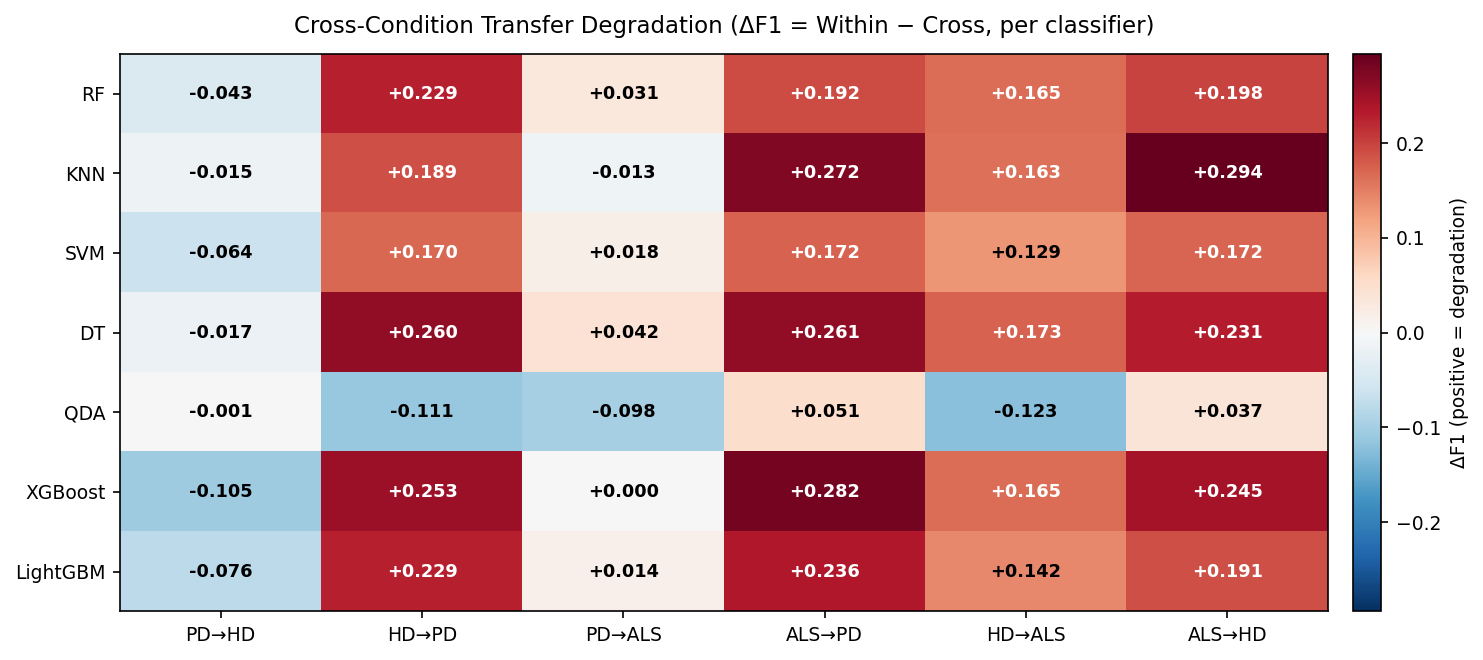

Saved: degradation_heatmap.pdf / .png


In [4]:
# Build matrix: rows = classifiers, cols = directions, using per-classifier within-F1
delta_matrix = np.zeros((len(CLF_NAMES), len(DIRECTIONS)))
for j, direction in enumerate(DIRECTIONS):
    src = direction.split('_to_')[0]
    for i, clf in enumerate(CLF_NAMES):
        delta_matrix[i, j] = WITHIN_F1_PER_CLF[src][clf] - cc[direction]['classifiers'][clf]['f1_macro']

abs_max = np.abs(delta_matrix).max()
vmax = max(abs_max, 0.01)   # guard against degenerate coloring

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(delta_matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(DIRECTIONS)))
ax.set_xticklabels(DIR_LABELS, rotation=0)
ax.set_yticks(range(len(CLF_NAMES)))
ax.set_yticklabels(CLF_LABELS)
ax.set_title('Cross-Condition Transfer Degradation (ΔF1 = Within − Cross, per classifier)', pad=10)

# Annotate each cell
for i in range(len(CLF_NAMES)):
    for j in range(len(DIRECTIONS)):
        val = delta_matrix[i, j]
        brightness = abs(val) / vmax
        color = 'white' if brightness > 0.55 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                fontsize=8.5, color=color, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('ΔF1 (positive = degradation)', fontsize=9)

fig.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES_DIR / f'degradation_heatmap.{ext}')
plt.show()
plt.close(fig)
print("Saved: degradation_heatmap.pdf / .png")


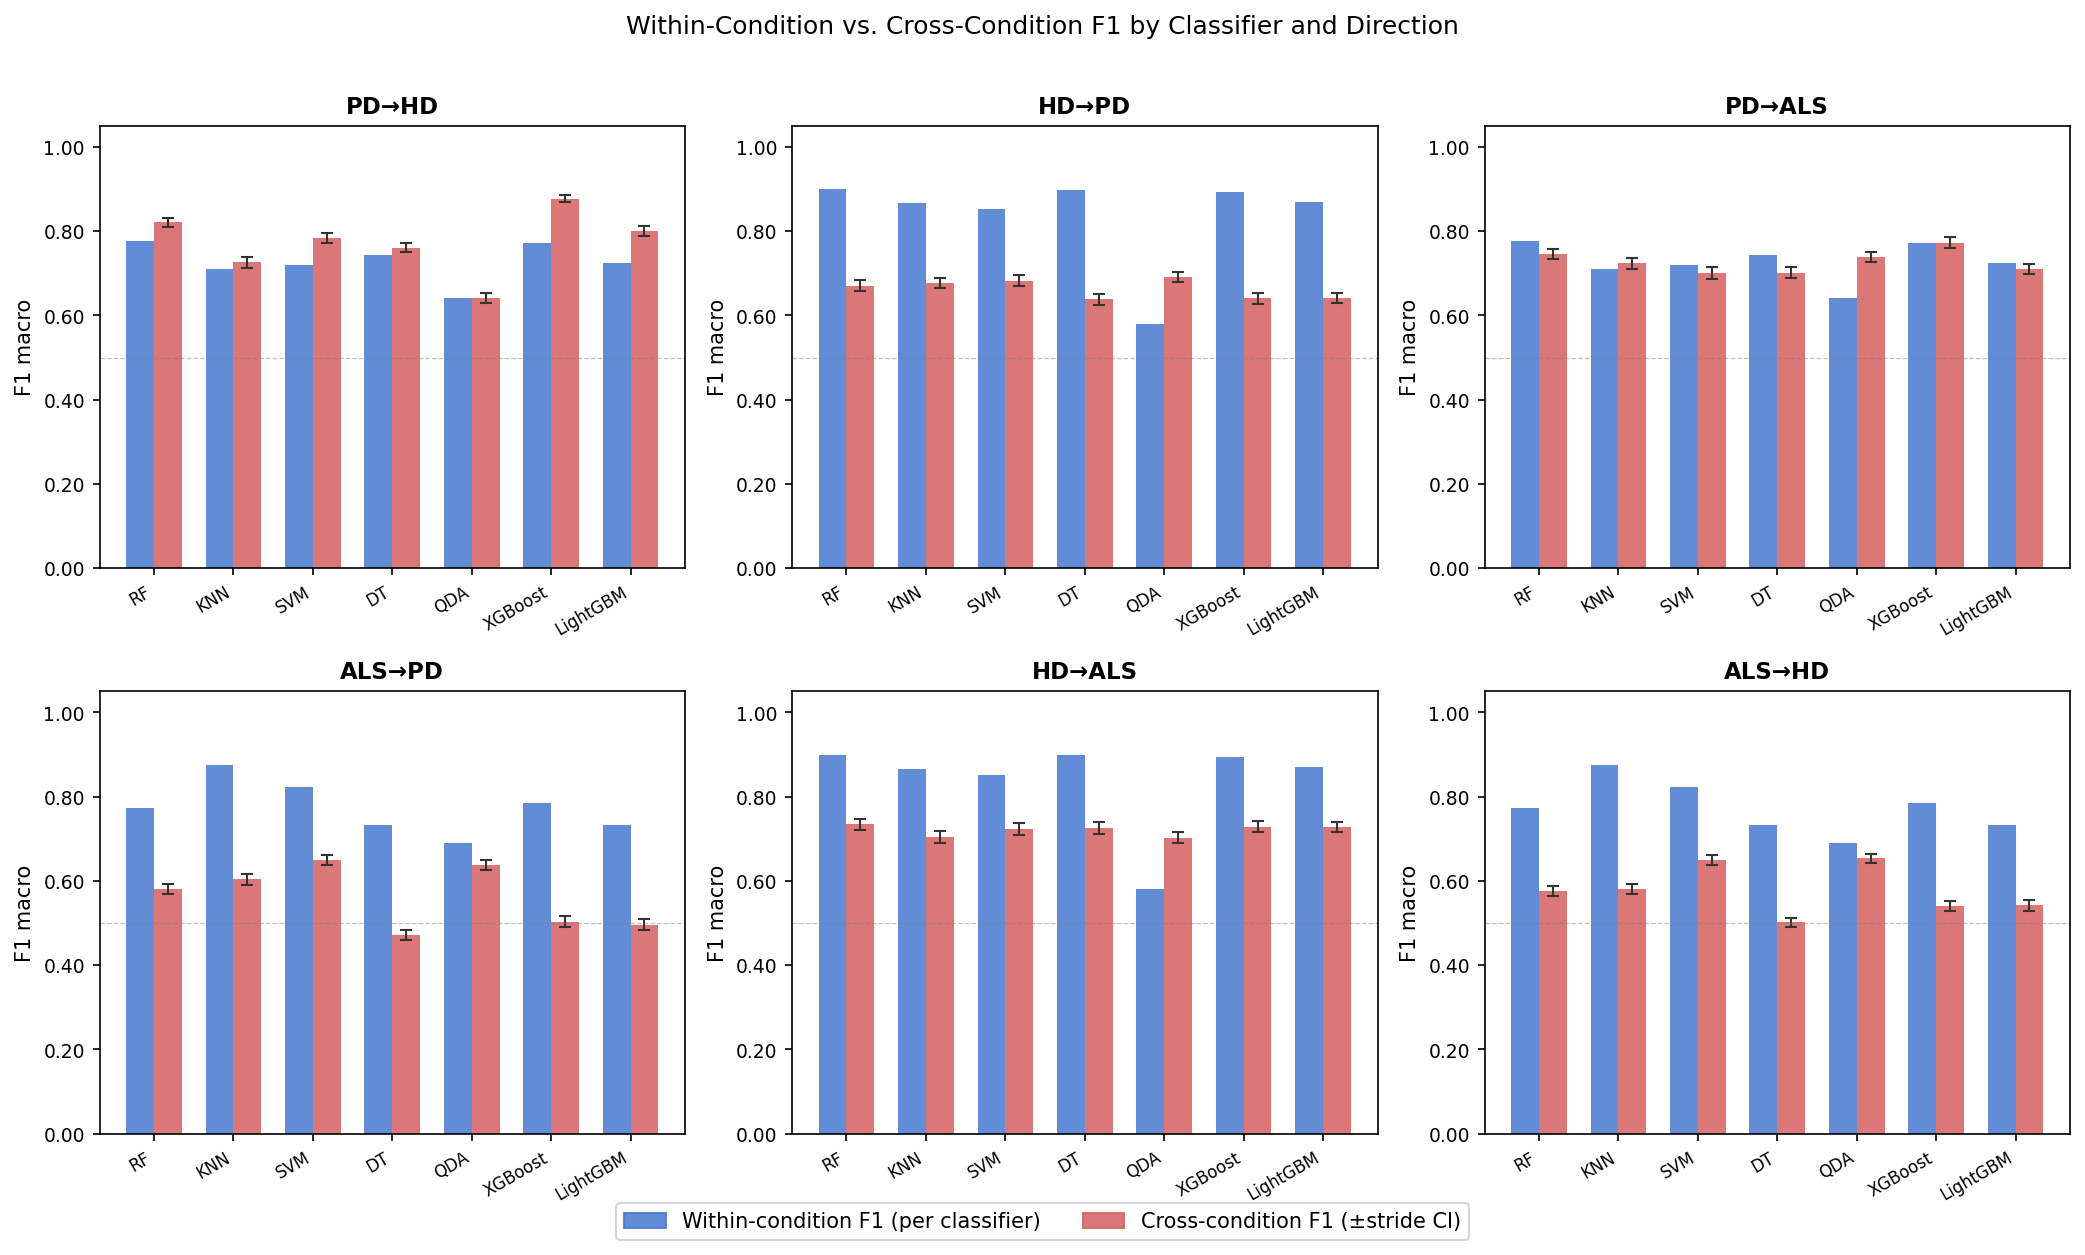

Saved: within_vs_cross_f1.pdf / .png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes_flat = axes.flatten()

color_within = '#4878CF'
color_cross  = '#D65F5F'

x = np.arange(len(CLF_NAMES))
width = 0.35

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    d = cc[direction]

    cross_f1s   = [d['classifiers'][clf]['f1_macro'] for clf in CLF_NAMES]
    ci_lowers   = [d['classifiers'][clf]['f1_macro_ci_lower'] for clf in CLF_NAMES]
    ci_uppers   = [d['classifiers'][clf]['f1_macro_ci_upper'] for clf in CLF_NAMES]
    ci_errs     = np.array([
        [c - lo for c, lo in zip(cross_f1s, ci_lowers)],
        [hi - c for c, hi in zip(cross_f1s, ci_uppers)],
    ])

    # Each classifier's own within-condition baseline (not a single shared value)
    within_bars = [WITHIN_F1_PER_CLF[src][clf] for clf in CLF_NAMES]

    b1 = ax.bar(x - width/2, within_bars, width, label='Within-condition',
                color=color_within, alpha=0.85)
    b2 = ax.bar(x + width/2, cross_f1s, width, label='Cross-condition',
                color=color_cross, alpha=0.85,
                yerr=ci_errs, capsize=3, ecolor='#333333', error_kw={'linewidth': 1})

    ax.set_title(dir_label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLF_LABELS, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 macro')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.axhline(0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

# Single legend outside the subplots
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_within, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_cross, alpha=0.85),
]
fig.legend(handles, ['Within-condition F1 (per classifier)', 'Cross-condition F1 (±stride CI)'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Within-Condition vs. Cross-Condition F1 by Classifier and Direction',
             fontsize=12, y=1.01)
fig.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES_DIR / f'within_vs_cross_f1.{ext}')
plt.show()
plt.close(fig)
print("Saved: within_vs_cross_f1.pdf / .png")


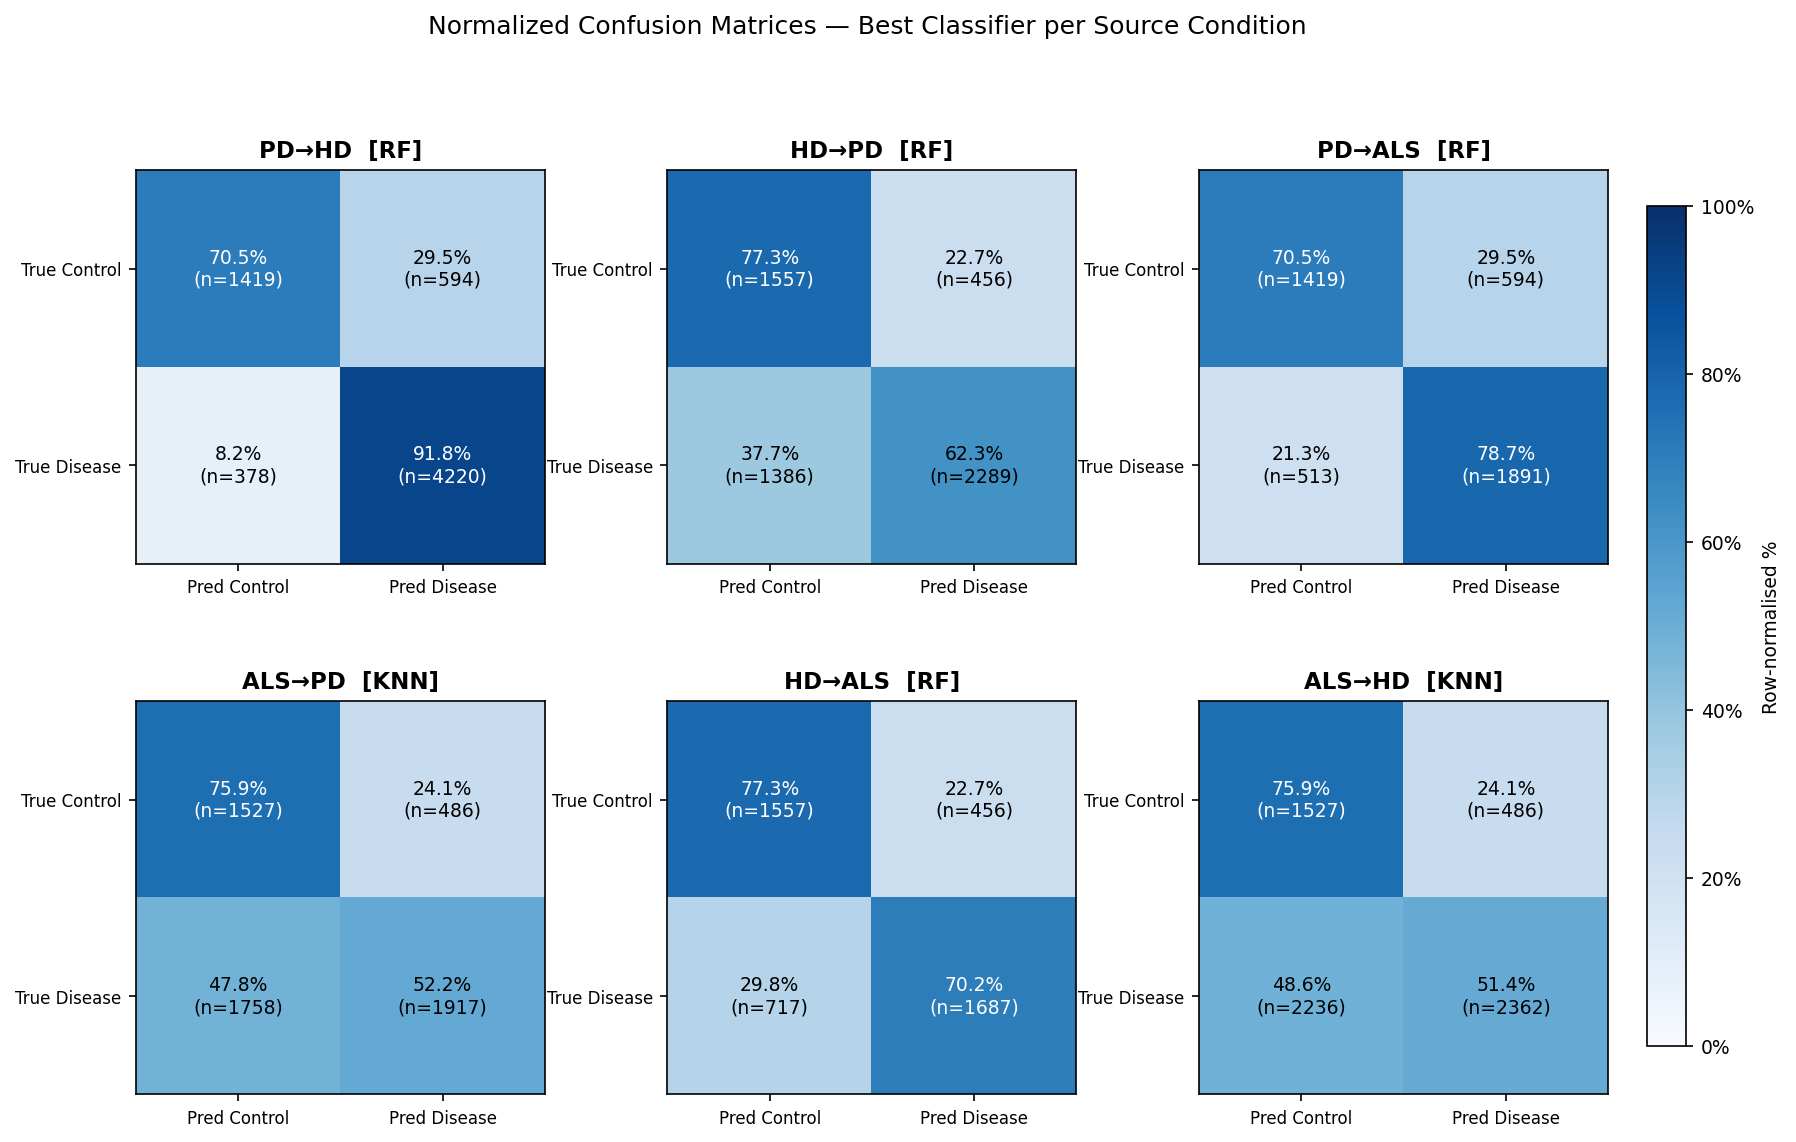

Saved: cross_condition_cms.pdf / .png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes_flat = axes.flatten()

last_im = None   # track final imshow handle for the shared colorbar

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    clf_name = BEST_CLF[src]
    v = cc[direction]['classifiers'][clf_name]

    y_true = np.array(v['y_true'])
    y_pred = np.array(v['y_pred'])

    cm = confusion_matrix(y_true, y_pred)
    # Row-normalize to percentages
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    last_im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100, aspect='auto')

    for r in range(2):
        for c in range(2):
            color = 'white' if cm_norm[r, c] > 65 else 'black'
            ax.text(c, r, f'{cm_norm[r, c]:.1f}%\n(n={cm[r, c]})',
                    ha='center', va='center', fontsize=9, color=color)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Control', 'Pred Disease'], fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Control', 'True Disease'], fontsize=8)
    ax.set_title(f'{dir_label}  [{clf_name.upper()}]', fontweight='bold')

# Manual colorbar placement to avoid overlapping subplots
fig.suptitle('Normalized Confusion Matrices — Best Classifier per Source Condition',
             fontsize=12, y=1.01)
fig.subplots_adjust(right=0.88, hspace=0.35, wspace=0.3)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
cbar = fig.colorbar(last_im, cax=cbar_ax, format='%.0f%%')
cbar.set_label('Row-normalised %', fontsize=9)

for ext in ('pdf', 'png'):
    fig.savefig(FIGURES_DIR / f'cross_condition_cms.{ext}')
plt.show()
plt.close(fig)
print("Saved: cross_condition_cms.pdf / .png")


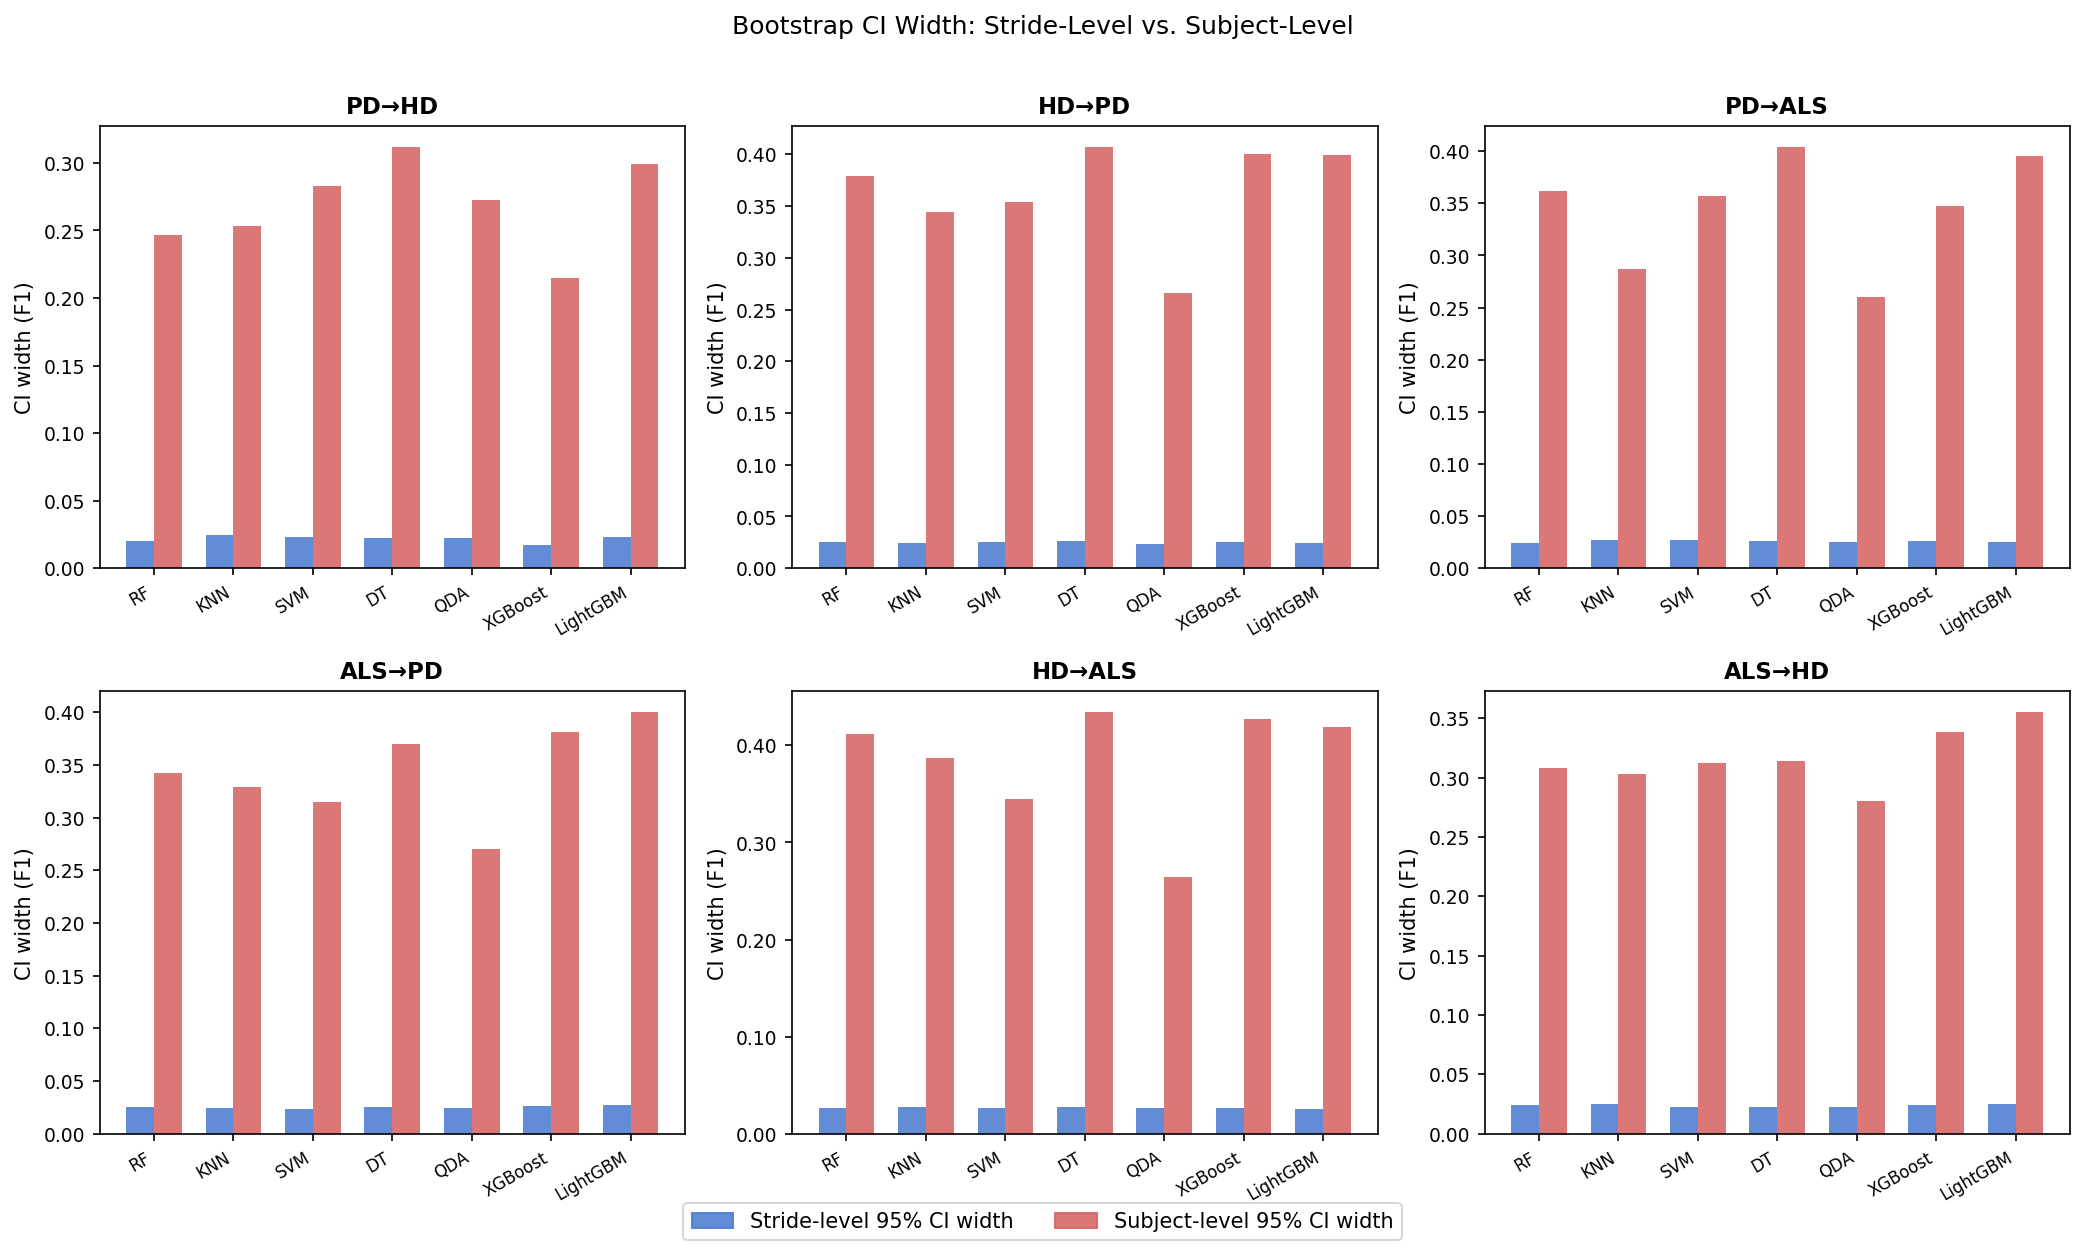

Saved: ci_width_comparison.pdf / .png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes_flat = axes.flatten()

color_stride = '#4878CF'
color_subj   = '#D65F5F'

x = np.arange(len(CLF_NAMES))
width = 0.35

for ax, direction, dir_label in zip(axes_flat, DIRECTIONS, DIR_LABELS):
    d = cc[direction]

    stride_widths = [
        d['classifiers'][clf]['f1_macro_ci_upper'] -
        d['classifiers'][clf]['f1_macro_ci_lower']
        for clf in CLF_NAMES
    ]
    subj_widths = [
        d['classifiers'][clf]['f1_macro_subj_ci_upper'] -
        d['classifiers'][clf]['f1_macro_subj_ci_lower']
        for clf in CLF_NAMES
    ]

    ax.bar(x - width/2, stride_widths, width, label='Stride-level CI',
           color=color_stride, alpha=0.85)
    ax.bar(x + width/2, subj_widths, width, label='Subject-level CI',
           color=color_subj, alpha=0.85)

    ax.set_title(dir_label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLF_LABELS, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('CI width (F1)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_stride, alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=color_subj,   alpha=0.85),
]
fig.legend(handles, ['Stride-level 95% CI width', 'Subject-level 95% CI width'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

fig.suptitle('Bootstrap CI Width: Stride-Level vs. Subject-Level',
             fontsize=12, y=1.01)
fig.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES_DIR / f'ci_width_comparison.{ext}')
plt.show()
plt.close(fig)
print("Saved: ci_width_comparison.pdf / .png")


,direction,clf,control_recall,disease_recall,f1_macro
0,PD→HD,RF,0.705,0.918,0.8208
1,HD→PD,RF,0.773,0.623,0.6707
2,PD→ALS,RF,0.705,0.787,0.7465
3,ALS→PD,KNN,0.759,0.522,0.6036
4,HD→ALS,RF,0.773,0.702,0.7342
5,ALS→HD,KNN,0.759,0.514,0.5816


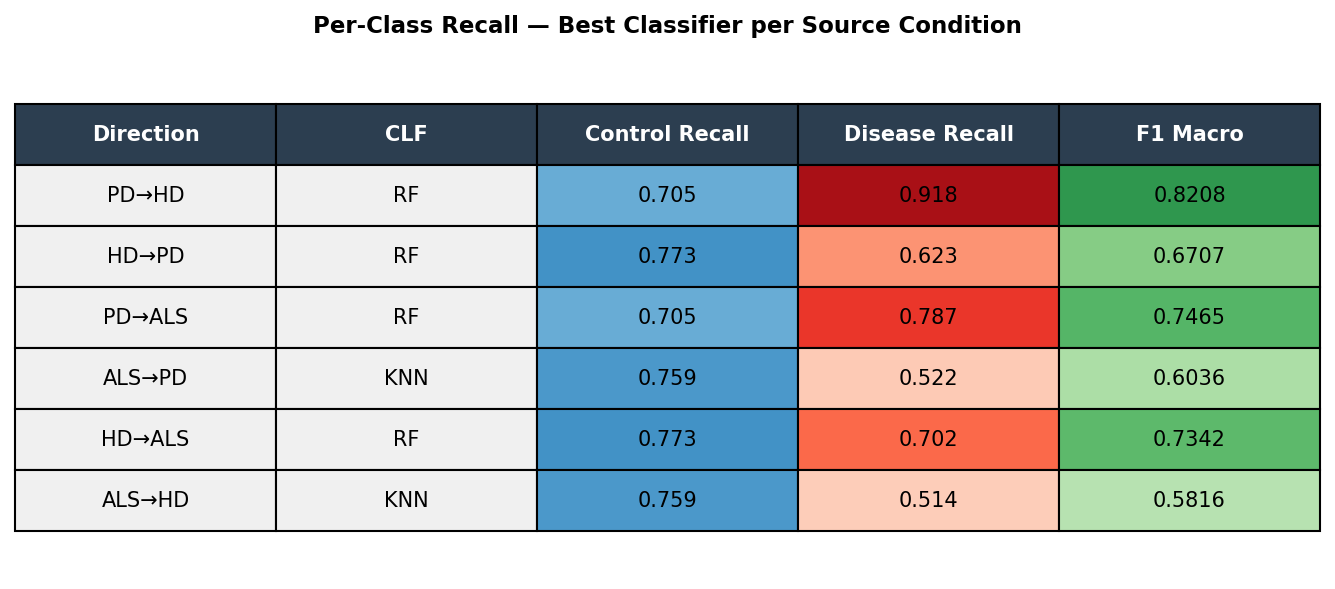

Saved: recall_table.pdf / .png


In [8]:
# \u2500\u2500 Per-class recall breakdown \u2014 best classifier per source condition \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# Control recall = fraction of control strides correctly classified as control.
# Disease recall = fraction of disease strides correctly classified as disease.
# These two numbers reveal the clinical failure mode: missed disease vs. false alarms.

recall_rows = []
for direction, dir_label in zip(DIRECTIONS, DIR_LABELS):
    src = direction.split('_to_')[0]
    clf_name = BEST_CLF[src]
    v = cc[direction]['classifiers'][clf_name]

    y_true = np.array(v['y_true'])
    y_pred = np.array(v['y_pred'])
    cm = confusion_matrix(y_true, y_pred)

    # cm[0,0] = true negatives (control correct), cm[0,1] = false positives
    # cm[1,0] = false negatives (disease missed), cm[1,1] = true positives
    control_recall = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else float('nan')
    disease_recall = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else float('nan')

    recall_rows.append({
        'direction':      dir_label,
        'clf':            clf_name.upper(),
        'control_recall': control_recall,
        'disease_recall': disease_recall,
        'f1_macro':       v['f1_macro'],
    })

df_recall = pd.DataFrame(recall_rows)

styled_recall = (
    df_recall.style
    .background_gradient(subset=['control_recall'], cmap='Blues', vmin=0.4, vmax=1.0)
    .background_gradient(subset=['disease_recall'], cmap='Reds',  vmin=0.4, vmax=1.0)
    .background_gradient(subset=['f1_macro'],       cmap='Greens', vmin=0.4, vmax=1.0)
    .format({
        'control_recall': '{:.3f}',
        'disease_recall': '{:.3f}',
        'f1_macro':       '{:.4f}',
    })
    .set_caption(
        'Per-Class Recall \u2014 Best Classifier per Source Condition\n'
        'Control recall: fraction of control strides correctly classified. '
        'Disease recall: fraction of disease strides correctly classified.'
    )
)
display(styled_recall)

# Matplotlib table for PDF rendering
import matplotlib.colors as mcolors
blues  = plt.cm.Blues
reds   = plt.cm.Reds
greens = plt.cm.Greens
norm   = mcolors.Normalize(vmin=0.4, vmax=1.0)

fig_r, ax_r = plt.subplots(figsize=(9, 4))
ax_r.axis('off')

col_labels_r = ['Direction', 'CLF', 'Control Recall', 'Disease Recall', 'F1 Macro']
table_data_r = []
cell_colors_r = []

for _, row in df_recall.iterrows():
    table_data_r.append([
        row['direction'],
        row['clf'],
        f"{row['control_recall']:.3f}",
        f"{row['disease_recall']:.3f}",
        f"{row['f1_macro']:.4f}",
    ])
    cell_colors_r.append([
        '#f0f0f0',
        '#f0f0f0',
        mcolors.to_hex(blues(norm(row['control_recall']))),
        mcolors.to_hex(reds(norm(row['disease_recall']))),
        mcolors.to_hex(greens(norm(row['f1_macro']))),
    ])

tbl_r = ax_r.table(
    cellText=table_data_r,
    colLabels=col_labels_r,
    cellColours=cell_colors_r,
    loc='center',
    cellLoc='center',
)
tbl_r.auto_set_font_size(False)
tbl_r.set_fontsize(10)
tbl_r.scale(1, 2.2)

# Header row: dark background, white bold text
for j in range(5):
    tbl_r[0, j].set_facecolor('#2c3e50')
    tbl_r[0, j].get_text().set_color('white')
    tbl_r[0, j].get_text().set_fontweight('bold')

fig_r.text(0.5, 0.97,
           'Per-Class Recall \u2014 Best Classifier per Source Condition',
           ha='center', va='top', fontsize=11, fontweight='bold')
fig_r.tight_layout(rect=[0, 0, 1, 0.93])
for ext in ('pdf', 'png'):
    fig_r.savefig(FIGURES_DIR / f'recall_table.{ext}')
plt.show()
plt.close(fig_r)
print("Saved: recall_table.pdf / .png")


## Results Narrative Stubs

*(Placeholders — full narrative will be written after Step 4 SHAP analysis is complete.)*

### PD → HD (best clf XGBoost F1 = 0.8773, ΔF1 = −0.0996 relative to HD within-RF)

The PD-trained XGBoost model achieves F1 = 0.8773 on the HD target pool, which exceeds the PD within-condition F1 of 0.7777 by +0.0996 — a negative degradation, meaning cross-condition transfer *improves* on the source ceiling.
This is consistent with the hypothesis that the control-vs-disease boundary for PD (asymmetry-driven) generalises well to HD when both share a common control class (Control B), and that HD pathology is sufficiently distinct from control to be captured by the PD feature space.
SHAP analysis (Step 4) is needed to confirm which features drive this generalization.

### HD → PD (best clf QDA F1 = 0.6912, ΔF1 = +0.2083)

The HD-trained QDA model achieves F1 = 0.6912 on the PD target pool, a degradation of +0.2083 from the HD within-condition ceiling of 0.8995.
This asymmetry confirms that the HD→PD direction is substantially harder than PD→HD: the HD model relies on high-variability features (CV_stride dominant in HD) that poorly discriminate PD from control.
All classifiers cluster in the 0.64–0.69 range, suggesting the degradation is feature-space driven rather than classifier-specific.

### PD → ALS (best clf XGBoost F1 = 0.7726, ΔF1 = +0.0051)

The PD-trained XGBoost model transfers near-perfectly to ALS (F1 = 0.7726 vs. PD within F1 = 0.7777, ΔF1 = +0.0051), a negligible degradation.
This suggests the PD vs. control boundary in feature space is similarly positioned relative to the ALS vs. control boundary — possibly because both conditions produce asymmetric or prolonged timing patterns that contrast with healthy control gait.
SHAP comparison across the two conditions will clarify whether the same features drive both classifications.

### ALS → PD (best clf SVM F1 = 0.6497, ΔF1 = +0.2261)

The ALS-trained SVM achieves only F1 = 0.6497 on PD, a degradation of +0.2261 from the ALS within-condition ceiling of 0.8758.
ALS classification relies on double-support-time features (progressive motor weakness signature) that do not capture PD's dopamine-deficit asymmetry pattern — a mechanistically distinct failure.
The ALS-source direction is the most asymmetric of the PD/ALS pair, confirming that the feature representations of the two conditions are not mutually transferable.

### HD → ALS (best clf XGBoost F1 = 0.7287, ΔF1 = +0.1708)

HD-trained XGBoost transfers to ALS with F1 = 0.7287, a degradation of +0.1708 from HD within F1 = 0.8995.
The HD model's reliance on stride variability (CV_stride) transfers partially to ALS — ALS does not produce HD-level variability, but the HD classifier's broader decision boundary may accommodate ALS's constrained, stereotyped gait.
Subject-level CIs are wide (e.g., RF: [0.51, 0.92]), indicating high individual variability in how well HD→ALS transfers across patients.

### ALS → HD (best clf QDA F1 = 0.6535, ΔF1 = +0.2223)

ALS-trained QDA achieves F1 = 0.6535 on HD, the second-largest degradation magnitude in the experiment.
ALS's tight, low-variability gait signature is the opposite of HD's high-variability choreiform movement — making this the most biomechanically dissimilar direction pair.
Wide subject CIs (e.g., RF: [0.41, 0.72]) suggest that HD subject-to-subject variability in gait pathology dominates the uncertainty in this direction.


## Summary of Key Findings

- **Transfer is highly asymmetric:** The PD→HD direction shows negative degradation (XGBoost F1 = 0.8773, exceeding the PD within-condition ceiling of 0.7777), while HD→PD degrades by +0.2083 — a difference of over 0.30 F1 units across the same condition pair. Asymmetry is present in all three bidirectional pairs.

- **ALS is the hardest source condition:** Both ALS→PD (best SVM F1 = 0.6497, ΔF1 = +0.2261) and ALS→HD (best QDA F1 = 0.6535, ΔF1 = +0.2223) show the largest degradations in the experiment. ALS's stereotyped double-support-dominant signature fails to generalize to either PD's asymmetry pattern or HD's variability pattern.

- **Subject-level CIs are 0.20–0.41 F1 units wider than stride-level CIs across all 42 entries:** The narrow stride-level CIs (0.012–0.028 wide) would substantially understate true uncertainty. Subject-level resampling reveals that transfer performance varies considerably across individual patients — the clinical implication is that zero-shot transfer reliability must be characterized at the patient level, not just across the full target pool.
